In [23]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Opgave 1. (10 point) Givet den øvre triangulære matrix {-}
$$
A =
\begin{bmatrix}
-6 & 4 & 5 \\
0 & 4 & 1 \\
0 & 0 & 7
\end{bmatrix}
$$
bestem tre egenværdier for $𝐴$.

Ifølge proposition 23.5 i notesættet kan man aflæse egenværdierne for en øvretrianuglær matrix som dens diagonal. Da $A$ er øvre triangulær er egenværdierne -6, 4 og 7. Svaret er dermed C

## Opgave 2. (10 point) Betragt matricen {-}
$$
\begin{bmatrix}
1 & -2 & 1 & 0 \\
1 & 1 & -1 & 1 \\
0 & 2 & -2 & 1
\end{bmatrix}
$$
Bestem en basis for nulrummet $𝑁(𝐴)$.

In [24]:
A = np.array([[1, -2, 1, 0],
              [1, 1, -1, 1],
              [0, 2, -2, 1]], dtype=float)

A[1] -= A[0]
A[1] /= 3
A[2] -= 2 * A[1]
A[2] /= A[2,2]
A[1] -= A[1,2] * A[2]
A[0] -= A[2]
A[0] += 2*A[1]
A

array([[ 1. ,  0. ,  0. ,  0.5],
       [ 0. ,  1. ,  0. ,  0. ],
       [-0. , -0. ,  1. , -0.5]])

Følgende ligninger opstilles:
$$
\begin{align*}
x_{0} + \frac{1}{2} x_{3} = 0 & \Leftrightarrow x_{0} = - \frac{1}{2} x_{3} \\
x_{1} = 0 & \\
x_{2} - \frac{1}{2} x_{3} = 0 & \Leftrightarrow x_{2} = \frac{1}{2} x_{3} \\
\end{align*}
$$

Den generelle løsning bliver:
$$
\begin{bmatrix}
x_{0} \\
x_{1} \\
x_{2} \\
x_{3}
\end{bmatrix}
=
\begin{bmatrix}
-\frac{1}{2} x_{3} \\
0 \\
\frac{1}{2} x_{3} \\
x_{3}
\end{bmatrix}
=
x_{3}
\begin{bmatrix}
- \frac{1}{2} \\
0 \\
\frac{1}{2} \\
1
\end{bmatrix}
$$

Nulrummet N(A) kan da udspændes af vektoren:
$$
N(A) = \text{span} \{
\begin{bmatrix}
- \frac{1}{2} \\
0 \\
\frac{1}{2} \\
1
\end{bmatrix}
\}
$$
Svaret er dermed B.

## Opgave 3. (10 point) Betragt enhedsvektoren {-}
$$
u =
\begin{bmatrix}
\frac{1}{2} \\
-\frac{1}{2} \\
\frac{1}{2} \\
-\frac{1}{2}
\end{bmatrix}
\in \mathbb{R}^{4}
$$
og sæt
$$
𝐴 = I_{4} − 2𝑢𝑢^{T}
$$
Hvilke af de følgende egenskaber gælder ikke for $𝐴$?

Når $uu^{T}$ udregnes vil hver indgang være sat til $u_{i} \cdot u_{j}$. Da ingen indgange i $u$ er 0 vil det da være umuligt at få en nedre triangulær matrix. Svaret er dermed D.

## Opgave 4. (10 point) For en matrix a i $\mathbb{R}^{400 \times 400}$ udregnes en 𝐿𝑈-dekomponering via den følgende funktion {-}
```py
def gauss_uden_ombytning(a):
    n, _ = a.shape
    u = np.copy(a)
    l = np.eye(n)
    for i in range(n-1):
        l[i+1:, [i]] = u[i+1:, [i]] / u[i,i]
        u[i+1:, i:] -= l[i+1:, [i]] @ u[[i], i:]
    return l, u
```

### (a) For i = 156 bestem størrelsen af matricen u[i+1:, i:], der udregnes i linje 7 af koden. {-}

Da u er en kopi af a vil den have størrelsen (400,400). Når der tages fra de første i+1 rækker og frem vil det da svare til at få de sidste $400 - (i+1)$ rækker. Det samme gælder for søjler men med i istedet, så $400- i$. Når $i=156$ bliver det da $400 - 157 = 243$ rækker og $400 - 156$ 244 søjler. Dens størrelse er da (243,244).

### (b) Angiv hvor mange flops der bruges i linje 6 af koden når i = 210. {-}

Når $i=210$ vil både l[i+1:, [i]] og u[i+1:, [i]] have størrelsen (189,1), mens u[i,i] er en skalar. Beregning i linje 6 består da af en enkel skalar-vektorprodukt på 189 flops.

## Opgave 5. (20 point) Betragt de følgende vektorer i $\mathbb{R}^{3}$: {-}
$$
v_{0} =
\begin{bmatrix}
\frac{1}{\sqrt{ 6 }} \\
\frac{1}{\sqrt{ 6 }} \\
\frac{2}{\sqrt{ 6 }}
\end{bmatrix}
, \qquad v_{1} =
\begin{bmatrix}
\frac{1}{\sqrt{ 2 }} \\
-\frac{1}{\sqrt{ 2 }} \\
0
\end{bmatrix}
, \qquad v_{2} =
\begin{bmatrix}
\frac{1}{\sqrt{ 3 }} \\
\frac{1}{\sqrt{ 3 }} \\
-\frac{1}{\sqrt{ 3 }}
\end{bmatrix}
$$

### (a) I python dan Grammatricen for $𝑣_{0},𝑣_{1},𝑣_{2}$. {-}

In [25]:
# Grammatricen dannes på baggrund af afsnit 9.3 i notesættet
v0 = np.array([1/np.sqrt(6), 1/np.sqrt(6), 2/np.sqrt(6)])[:, np.newaxis]
v1 = np.array([1/np.sqrt(2), -1/np.sqrt(2), 0])[:, np.newaxis]
v2 = np.array([1/np.sqrt(3), 1/np.sqrt(3), -1/np.sqrt(3)])[:, np.newaxis]

V = np.column_stack((v0, v1, v2))
G = V.T @ V
G

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### (b) Brug Grammatricen til at argumentere for at $𝐸 : 𝑣_{0},𝑣_{1},𝑣_{2}$ er en ortonormal basis for $\mathbb{R}^{3}$. {-}

Ifølge Lemma 9.8 i notesættet er en samling vektorer ortonormal, hvis grammatricen til dem er lig identitetsmatricen. Det kan ses i ovenstående resultat, at de er det for $\mathbb{R}^{3}$. 

### (c) Beregn koordinatvektoren $[b]_{𝐸}$ af {-}
$$
b =
\begin{bmatrix}
1 \\
1 \\
1
\end{bmatrix}
$$
med hensyn til den ortonormale basis $𝐸 : 𝑣_{0},𝑣_{1},𝑣_{2}$.

Definition 19.6 fra notesættet siger at koordinatvektoren med hensyn til basen kan findes ved at løse det lineær ligningssystem:
$$
A x = b, \qquad A = (v_{0}, v_{1})
$$
Denne ligning vil løses ved at reducere til echelon form og derefter lave back substitution.

In [26]:
b = np.array([1, 1, 1])[:, np.newaxis]
A = np.column_stack((V, b))

A[0] /= A[0,0]
A[1] -= A[1,0] * A[0]
A[1] /= A[1,1]
A[2] -= A[2,0] * A[0]
A[2] -= A[2,1] * A[1]
A[2] /= A[2,2]
A[0] -= A[0,1] * A[1]
A[0] -= A[0,2] * A[2]
A

array([[ 1.        ,  0.        ,  0.        ,  1.63299316],
       [-0.        ,  1.        , -0.        , -0.        ],
       [-0.        , -0.        ,  1.        ,  0.57735027]])

In [27]:
bE = A[:, [3]]
print(f"Koordinatvektoren mht basen E vil da være: \n{bE}")

Koordinatvektoren mht basen E vil da være: 
[[ 1.63299316]
 [-0.        ]
 [ 0.57735027]]


### (d) Bestem en symmetrisk matrix $𝐴$ der har $𝑣_{0}$, $𝑣_{1}$ og $𝑣_{2}$ som egenvektorer med tilhørende egenværdier $𝜆_{0}=18$, $𝜆_{1}=6$ og $𝜆_{2}=3$. Brug derefter np.linalg.eig(...) til at bekræfte at dit svar er rigtig. {-}

Ifølge sætning 23.10 i notesættet vil symmetriske matricer kunne dekomponeres til formen
$$
A = V \Lambda V^{T}
$$
hvor $V$ er en ortogonal matrix og $\Lambda$ er en diagonal matrix. Dette gælder specielt for reelle egenværdier og deres tilhørende egenvektorer. Den symmetriske matrix kan da opstilles ligeledes.

In [28]:
lambda0 = 18
lambda1 = 6
lambda2 = 3
Lambda = np.diag((lambda0, lambda1, lambda2))

A = V @ Lambda @ V.T
A

array([[ 7.,  1.,  5.],
       [ 1.,  7.,  5.],
       [ 5.,  5., 13.]])

In [29]:
# selvom vektorerne ikke er skrevet op på samme vis kan det ses at matricen, A, passer
eigval, eigvec = np.linalg.eig(A)
print(eigval)
print(np.array([lambda0, lambda1, lambda2], dtype=float))
print(eigvec)
print(V)

[18.  6.  3.]
[18.  6.  3.]
[[-4.08248290e-01 -7.07106781e-01 -5.77350269e-01]
 [-4.08248290e-01  7.07106781e-01 -5.77350269e-01]
 [-8.16496581e-01  4.46047665e-18  5.77350269e-01]]
[[ 0.40824829  0.70710678  0.57735027]
 [ 0.40824829 -0.70710678  0.57735027]
 [ 0.81649658  0.         -0.57735027]]


## Opgave 6. (20 point) Betragt de følgende datapunkter {-}

| s   | 10.5 | 13.7 | 14.9 | 15.6 | 15.9 | 16.4 | 18.6 | 19.4 |
| --- |  --- |  --- |  --- |  --- |  --- |  --- |  --- |  --- |
| t   | 2.24 | 2.56 | 2.98 | 1.47 | 2.28 | 2.97 | 3.97 | 8.26 |

Der ønskes et polynomium $𝑃_{4}(𝑠) = 𝑎𝑠^{4} + 𝑏𝑠^{3} + 𝑐𝑠^{2} + 𝑑𝑠 + 𝑒$, der går igennem punkterne.

### (a) Ved hjælp af funktionen np.vander(...) opstil et lineært ligningssystem $𝐴𝑥 = 𝑢$, som svarer til problemstillingen. Forklar hvorfor der kan ikke forventes en eksakt løsning. {-}

In [30]:
# Da koefficienterne i polynomiet er baseret på s, 
# vil datapunkterne for s svare til koefficientmatricen
s_data = np.array([10.5, 13.7, 14.9, 15.6, 15.9, 16.4, 18.6, 19.4])
A = np.vander(s_data, 5)    # np.vander for potenserne

# t må da være målet som polynomiet skal ramme for hver s
u = np.array([2.24, 2.56, 2.98, 1.47, 2.28, 2.97, 3.97, 8.26])[:, np.newaxis]

# x svarer til vektoren (a, b, c, d, e)
print(f"det lineære ligningssystem bliver dermed: \n{A} \nx = \n{u}")

det lineære ligningssystem bliver dermed: 
[[1.21550625e+04 1.15762500e+03 1.10250000e+02 1.05000000e+01
  1.00000000e+00]
 [3.52275361e+04 2.57135300e+03 1.87690000e+02 1.37000000e+01
  1.00000000e+00]
 [4.92884401e+04 3.30794900e+03 2.22010000e+02 1.49000000e+01
  1.00000000e+00]
 [5.92240896e+04 3.79641600e+03 2.43360000e+02 1.56000000e+01
  1.00000000e+00]
 [6.39128961e+04 4.01967900e+03 2.52810000e+02 1.59000000e+01
  1.00000000e+00]
 [7.23394816e+04 4.41094400e+03 2.68960000e+02 1.64000000e+01
  1.00000000e+00]
 [1.19688322e+05 6.43485600e+03 3.45960000e+02 1.86000000e+01
  1.00000000e+00]
 [1.41646850e+05 7.30138400e+03 3.76360000e+02 1.94000000e+01
  1.00000000e+00]] 
x = 
[[2.24]
 [2.56]
 [2.98]
 [1.47]
 [2.28]
 [2.97]
 [3.97]
 [8.26]]


Det kan ses at der er flere rækker en søjler i koefficientmatricen, hvilket vil sige at man ikke kan forvente en eksakt løsning, som rammer alle datapunkter med kun et fjerdegradspolynomium. 

### (b) Ved brug af en tynd $𝑄𝑅$-dekomponering konstrueret via den forbedrede Gram-Schmidt proces, bestem i python de mindste kvadraters løsninger til systemet $𝐴𝑥 = 𝑢$. {-}

In [31]:
# Fra afsnit 15.3 i notesættet
def forbedret_gram_schmidt(a):
    _, k = a.shape
    q = np.copy(a)
    r = np.zeros((k, k))
    for i in range(k):
        r[i, i] = np.linalg.norm(q[:, i])
        q[:, i] /= r[i, i]
        r[[i], i+1:] = q[:, [i]].T @ q[:, i+1:]
        q[:, i+1:] -= q[:, [i]] @ r[[i], i+1:]
    return q, r

# Fra afsnit 16.4 i notesættet
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

In [32]:
# Resultaterne fra QR-dekomponeringen samt u indsættes i ligning 16.4 fra notesættet
q, r = forbedret_gram_schmidt(A)
QTu = q.T @ u
x = back_subs(r, QTu)
x

array([[ 1.76396943e-02],
       [-1.01202631e+00],
       [ 2.15128891e+01],
       [-2.00612586e+02],
       [ 6.94017652e+02]])

### (c) Giv en python plot af datapunkterne og de to polynomiet $𝑃_{4}$ bestemt af din løsning. {-}

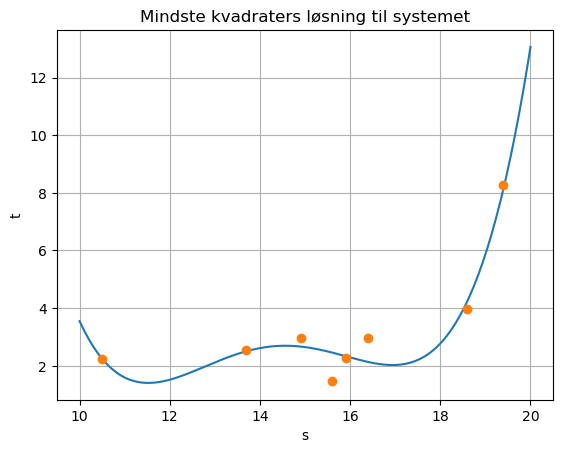

In [33]:
s = np.linspace(10, 20, 200)
t = x[0]*s**4 + x[1]*s**3 + x[2]*s**2 + x[3]*s + x[4]

fig, ax = plt.subplots()
ax.plot(s, t)
ax.plot(s_data, u, "o")
ax.set_xlabel('s')
ax.set_ylabel('t')
ax.set_title('Mindste kvadraters løsning til systemet')
ax.grid()

### (d) Beregn restvektoren for din løsning. I hvilke datapunkt er der størst afvigelse fra den oprindelige data? {-}

In [34]:
# Restvektoren beregnes som vist i afsnit 16.1 i notesættet
r = u - A @ x
r

array([[-0.006151  ],
       [ 0.05454556],
       [ 0.31178034],
       [-0.98995481],
       [-0.05406368],
       [ 0.83715334],
       [-0.27448272],
       [ 0.12117297]])

In [35]:
print(f"Det kan ses at den største afvigelse er på -0.99 fra dataen, \
      \nhvilket er for punktet {s_data[3], u[3,0]}")

Det kan ses at den største afvigelse er på -0.99 fra dataen,       
hvilket er for punktet (15.6, 1.47)


## Opgave 7. (20 point) Betragt afbildningen $𝐿: \mathbb{R}^{5} \to \mathbb{R}^{2}$ givet ved {-}
$$
L(s,t,x,y,z) = (2s - 3x + 4y - z, 3t + 2x - 3y + 2z)
$$

### (a) Gør rede for at $𝐿$ er en lineær afbildning med standard matrix repræsentation $𝐴$ givet ved {-}
$$
A =
\begin{bmatrix}
2 & 0 & -3 & 4 & -1 \\
0 & 3 & 2 & -3 & 2
\end{bmatrix}
$$

For at $L$ kan være en lineær afbildning skal den følge egenskab (b) af proposition 18.12. Dette kan tjekkes ved at opskrive relationen således:
$$
\begin{align*}
L(su + tv) & =
su + tv
\left(
\begin{bmatrix}
2 \\
0 \\
-3 \\
4 \\
-1
\end{bmatrix}
+
\begin{bmatrix}
0 \\
3 \\
2 \\
-3 \\
2
\end{bmatrix}
\right) \\
 & =
\begin{bmatrix}
2su_{0} \\
0 \\
-3su_{2} \\
4su_{3} \\
-su_{4}
\end{bmatrix}
+
\begin{bmatrix}
0 \\
3su_{1} \\
2su_{2} \\
-3su_{3} \\
2su_{4}
\end{bmatrix}
+
\begin{bmatrix}
2tv_{0} \\
0 \\
-3tv_{2} \\
4tv_{3} \\
-tv_{4}
\end{bmatrix}
+
\begin{bmatrix}
0 \\
3tv_{1} \\
2tv_{2} \\
-3tv_{3} \\
2tv_{4}
\end{bmatrix} \\
 & =
s \cdot \left(
\begin{bmatrix}
2u_{0} \\
0 \\
-3u_{2} \\
4u_{3} \\
-u_{4}
\end{bmatrix}
+
\begin{bmatrix}
0 \\
3u_{1} \\
2u_{2} \\
-3u_{3} \\
2u_{4}
\end{bmatrix} \right)
+
t \cdot \left(
\begin{bmatrix}
2v_{0} \\
0 \\
-3v_{2} \\
4v_{3} \\
-v_{4}
\end{bmatrix}
+
\begin{bmatrix}
0 \\
3v_{1} \\
2v_{2} \\
-3v_{3} \\
2v_{4}
\end{bmatrix}\right) \\
 & = s \cdot L(u) + t \cdot L(v)
\end{align*}
$$

Da $L(su + tv) = s \cdot L(u) + t \cdot L(v)$ er $L$ en lineær transformation.

Ud fra proposition 18.14 vides det at for alle søjler i A skal det gælde at:
$$
u_{j} = L(e_{j})
$$
Dette tjekkes i numpy således:

In [36]:
A = np.array([[2, 0, -3, 4, -1],
              [0, 3, 2, -3, 2]], dtype=float)

def L(s, t, x, y , z):
    result = np.zeros((2,1))
    result[0] = 2*s - 3*x + 4*y - z
    result[1] = 3*t + 2*x - 3*y + 2*z
    return result

for i in range(5):
    # definerer basisvektor
    e = np.zeros((5,1))
    e[i] = 1

    # når A[:, i] kaldes blive det til en liste, så [:, np.newaxis] gør det til en vektor igen
    print(np.all(A[:,i][:, np.newaxis] == L(e[0], e[1], e[2], e[3], e[4])))

True
True
True
True
True


## (b) I python brug en iterationsmetode til et bestemme den største singulærværdi $𝜎_{0}$ af $𝐴$ og tilhørende singulære vektorer $𝑣_{0} \in \mathbb{R}^{5}$ og $𝑢_{0} \in \mathbb{R}^{2}$. {-}

En metode til at finde den største singulærværdi til en matrix som også bruger iteration er potensmetoden.

In [37]:
# Fra eksempel 24.8 i notesættet
def sing_skridt_del(a, v):
    w = a @ v
    sigma = np.linalg.norm(w)
    u = w / sigma
    return sigma, u

In [38]:
# Følger eksempel 24.8 i notesættet
rng = np.random.default_rng()

m, n = A.shape
u = np.ones((m,1))
v = rng.standard_normal((n, 1))
v /= np.linalg.norm(v)
len = 20
sigma_out = np.zeros(2*len)

for k in range(len):
    sigma_out[2*k], u = sing_skridt_del(A, v)
    sigma_out[2*k+1], v = sing_skridt_del(A.T, u)

sigma0 = sigma_out[-1]
v0 = np.copy(v)
u0 = np.copy(u)

print(f"Den største singulærværdi er: {sigma0} \n\nSingulærvektoren v0 er: \n{v0} \n\nSingulærvektoren u0 er: \n{u0}")

Den største singulærværdi er: 6.935398419863258 

Singulærvektoren v0 er: 
[[-0.21381685]
 [ 0.29025239]
 [ 0.51422687]
 [-0.7178861 ]
 [ 0.30041002]] 

Singulærvektoren u0 er: 
[[-0.74145253]
 [ 0.67100532]]


### (c) Skriv $u_{0} = \begin{bmatrix}a\\b\end{bmatrix}$ og sæt $u_{1} = \begin{bmatrix}-b\\a\end{bmatrix}$. Bekræft, uden brug af funktioner som np.linalg.svd(...), at $𝑢_{1}$ er en singulærvektor for $𝐴$ og bestem den tilhørende singulærværdi $𝜎_{1}$. {-}

Det kan ses i eksempel 10.3 i notesættet at SVD formen kan omskrives til en tynd SVD således:
$$
A = \sigma_{0} u_{0} v_{0}^{T} + \sigma_{1} u_{1} v_{1}^{T}
$$
Derudover vides det, at det yderligere kan omskrives som i bemærkning 10.1:
$$
A^{T} u_{0} = \sigma_{0} v_{0}, \qquad A^{T} u_{1} = \sigma_{1} v_{1}
$$
Her kan $A^{T} u_{1}$ beregnes med de kendte værdier (antaget at $u_{1}$ er en singulærvektor). Derudover vides det at $v_{1}$ må være af længden 1, da samlingen af alle $v_{i}$ skal være ortonormal. $v_{1}$ kan da findes som $\frac{\sigma_{1} v_{1}}{||\sigma_{1} v_{1}||_{2}}$. Hvorefter sigma kan findes som skaleringsfaktoren for en af indgangene fra $\sigma_{1} v_{1}$ til $v_{1}$.

In [39]:
u1 = np.array([-u[1,0], u[0,0]])[:, np.newaxis]
sigmav1 = A.T @ u1
v1 = sigmav1 / np.linalg.norm(sigmav1, 2)
sigma1 = (sigmav1[0,0]/v1[0,0])
sigma1

2.8107381161819784

In [40]:
# Det kan bekræftes at denne SVD passer (og dermed u1) med eksempel 10.3
machine_epsilon = np.finfo(float).eps

np.allclose(A, sigma0 * u0 @ v0.T + sigma1 * u1 @ v1.T, rtol=machine_epsilon, atol=machine_epsilon)

True

### (d) Bestem konditionstallet for $𝐴$ og bekræft at det stemmer overens med svaret fra np.linalg.cond(...). Bestem desuden hvilke relativfejl man kan forvente i udregning af $𝐴𝑣$ for et vilkårligt $𝑣 \in \mathbb{R}^{5}$. {-}

In [46]:
# Konditionstallet findes gennem ligning 11.10 i notesættet
kA = sigma0 / sigma1

print("Konditionstallet for A er:", kA)
print("Kontrol:", np.linalg.cond(A))

Konditionstallet for A er: 2.4674651757610535
Kontrol: 2.4674651757610535


In [45]:
# Den relative fejl findes som konditionstallet ganget med machine epsilon
kA * machine_epsilon

5.478873301181361e-16